In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bofulee/kevin-hillstrom-minethatdata-e-mailanalytics")

print("Path to dataset files:", path)

100%|██████████| 497k/497k [00:00<00:00, 75.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bofulee/kevin-hillstrom-minethatdata-e-mailanalytics/versions/1


Loaded: Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
Rows: 64000
   recency history_segment  history  mens  womens   zip_code  newbie channel  \
0       10  2) $100 - $200   142.44     1       0  Surburban       0   Phone   
1        6  3) $200 - $350   329.08     1       1      Rural       1     Web   
2        7  2) $100 - $200   180.65     0       1  Surburban       1     Web   
3        9  5) $500 - $750   675.83     1       0      Rural       1     Web   
4        2    1) $0 - $100    45.34     1       0      Urban       0     Web   

         segment  visit  conversion  spend  
0  Womens E-Mail      0           0    0.0  
1      No E-Mail      0           0    0.0  
2  Womens E-Mail      0           0    0.0  
3    Mens E-Mail      0           0    0.0  
4  Womens E-Mail      0           0    0.0  
Training Data Shape: (42613, 15)
Features used: ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_Surburban', 'zip_code_Urban', 'channel_P

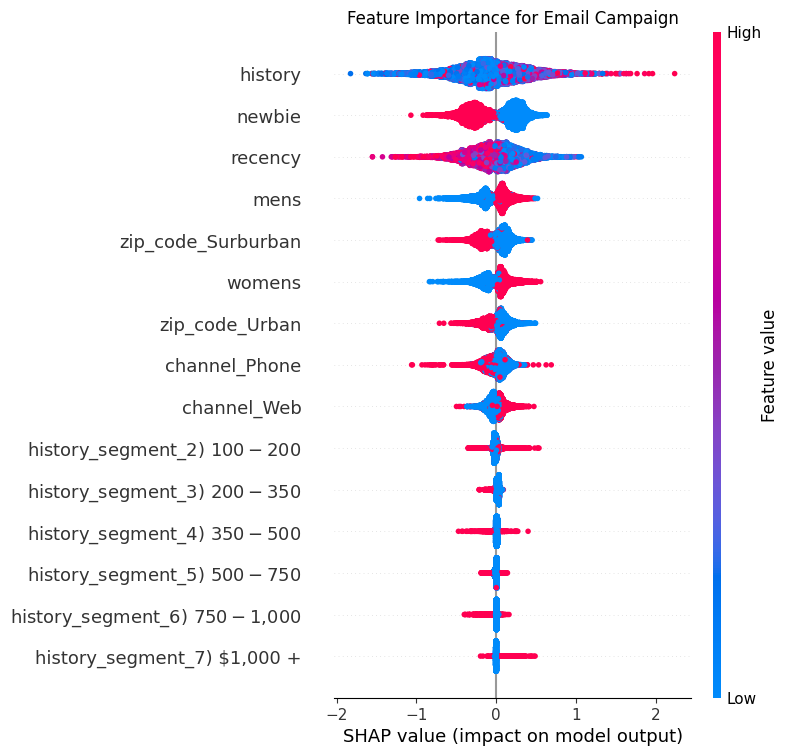

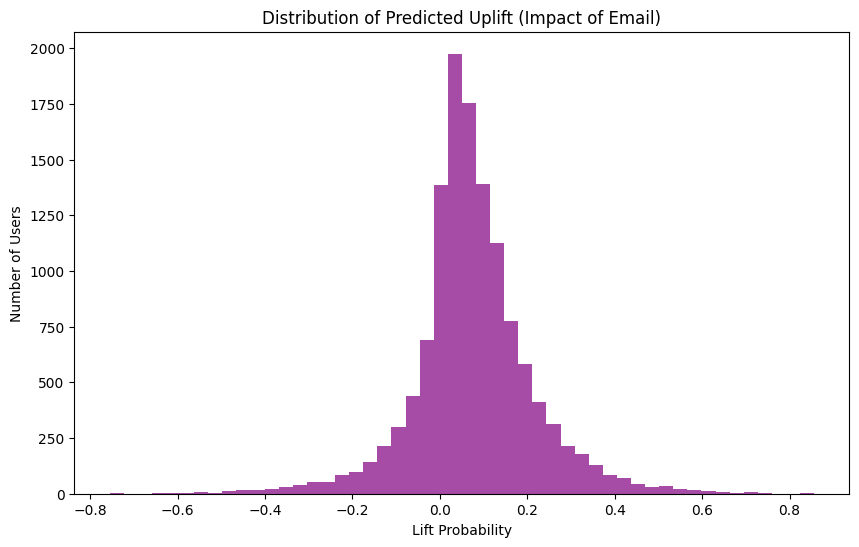

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD DATASET FROM YOUR PATH
# ==========================================
# Use the path output you got:
download_path = "/root/.cache/kagglehub/datasets/bofulee/kevin-hillstrom-minethatdata-e-mailanalytics/versions/1"

# Find the CSV file inside the folder automatically
csv_file = [f for f in os.listdir(download_path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(download_path, csv_file))

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")
print(df.head())

# ==========================================
# 2. DATA PREPROCESSING (FIXED)
# ==========================================

# Filter for A/B Test (Men's Email vs No Email)
df = df[df['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()

# Define Treatment (1 = Email, 0 = No Email)
df['treatment'] = np.where(df['segment'] == 'Mens E-Mail', 1, 0)

# Define Target (1 = Visit/Conversion)
df['conversion'] = df['visit']

# --- THE FIX: ENCODE ALL TEXT COLUMNS ---
# We need to convert 'zip_code', 'channel', AND 'history_segment' to numbers.
categorical_cols = ['zip_code', 'channel', 'history_segment']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define Feature Columns (X)
# We want everything EXCEPT the target variables
drop_cols = ['segment', 'visit', 'conversion', 'spend', 'treatment']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['conversion']
t = df['treatment']

print(f"Training Data Shape: {X.shape}")
print(f"Features used: {list(X.columns)}")

# ==========================================
# 3. UPLIFT MODELING (The T-Learner)
# ==========================================
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(X, y, t, test_size=0.3, random_state=42)

# Control Model (Trained on users who got NO email)
model_ctrl = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model_ctrl.fit(X_train[t_train == 0], y_train[t_train == 0])

# Treatment Model (Trained on users who GOT email)
model_treat = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model_treat.fit(X_train[t_train == 1], y_train[t_train == 1])

print("\nModels Trained Successfully.")

# ==========================================
# 4. PREDICTING LIFT (Individual Treatment Effect)
# ==========================================
# For every user in the Test Set, we ask:
# "What is prob(buy) if we DON'T email them?" (Counterfactual 0)
# "What is prob(buy) if we DO email them?" (Counterfactual 1)

pred_prob_ctrl = model_ctrl.predict_proba(X_test)[:, 1]
pred_prob_treat = model_treat.predict_proba(X_test)[:, 1]

# Uplift = P(Buy | Email) - P(Buy | No Email)
uplift_score = pred_prob_treat - pred_prob_ctrl

results = X_test.copy()
results['uplift_score'] = uplift_score
results['actual_treatment'] = t_test
results['actual_conversion'] = y_test

# ==========================================
# 5. ROI & BUSINESS IMPACT
# ==========================================
# Let's verify if targeting high-uplift users actually makes more money.

# Strategy: Target top 30% of users with highest Uplift
threshold = results['uplift_score'].quantile(0.7)
results['targeted'] = (results['uplift_score'] > threshold).astype(int)

# Simple ROI Calc:
# Assume Email Cost = $0.10
# Assume Revenue per Conversion = $100 (Avg basket size)
email_cost = 0.10
revenue_per_conversion = 100

def calculate_economics(df_subset):
    # Cost = Number of emails sent * Cost per email
    total_cost = df_subset['targeted'].sum() * email_cost

    # Expected Revenue = Sum of (Prob_Treat if targeted else Prob_Ctrl) * Rev Per Conversion
    expected_conv = np.where(df_subset['targeted'] == 1, pred_prob_treat, pred_prob_ctrl).sum()
    total_rev = expected_conv * revenue_per_conversion

    return total_rev - total_cost

ai_profit = calculate_economics(results)
random_profit = (results['actual_conversion'].sum() * revenue_per_conversion) - (len(results) * email_cost)

print(f"\n--- BUSINESS IMPACT ---")
print(f"Projected AI Strategy Profit: ${ai_profit:,.2f}")
print(f"Baseline (Mass Email) Profit: ${random_profit:,.2f}")
print(f"Incremental Value: ${ai_profit - random_profit:,.2f}")

# ==========================================
# 6. EXPLAINABILITY (SHAP)
# ==========================================
# Why did the model target certain people?

explainer = shap.TreeExplainer(model_treat)
shap_values = explainer.shap_values(X_test)


plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Importance for Email Campaign")
plt.show()

# Distribution of Uplift
plt.figure(figsize=(10, 6))
plt.hist(uplift_score, bins=50, color='purple', alpha=0.7)
plt.title("Distribution of Predicted Uplift (Impact of Email)")
plt.xlabel("Lift Probability")
plt.ylabel("Number of Users")
plt.show()

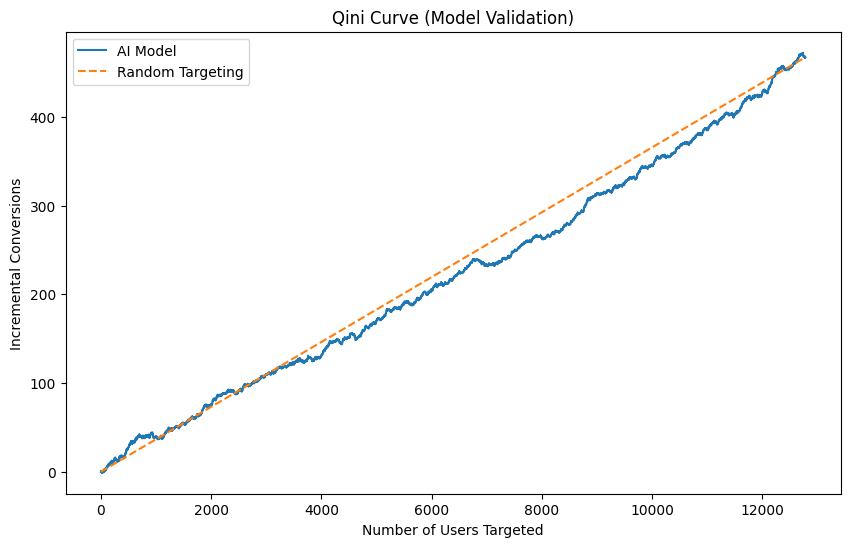

In [5]:
# ==========================================
# 7. MODEL VALIDATION (Qini Curve)
# ==========================================
# Sort users by predicted uplift (High to Low)
results_sorted = results.sort_values(by='uplift_score', ascending=False)

# Calculate cumulative incremental gains
results_sorted['cumsum_tr'] = results_sorted['actual_treatment'].cumsum()
results_sorted['cumsum_ct'] = (1 - results_sorted['actual_treatment']).cumsum()

results_sorted['cumsum_y_tr'] = (results_sorted['actual_conversion'] * results_sorted['actual_treatment']).cumsum()
results_sorted['cumsum_y_ct'] = (results_sorted['actual_conversion'] * (1 - results_sorted['actual_treatment'])).cumsum()

# Uplift Curve Calculation
results_sorted['uplift_curve'] = results_sorted['cumsum_y_tr'] - (results_sorted['cumsum_y_ct'] * (results_sorted['cumsum_tr'] / results_sorted['cumsum_ct']))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(results_sorted)), results_sorted['uplift_curve'], label='AI Model')
plt.plot([0, len(results_sorted)], [0, results_sorted['uplift_curve'].iloc[-1]], linestyle='--', label='Random Targeting')
plt.xlabel('Number of Users Targeted')
plt.ylabel('Incremental Conversions')
plt.title('Qini Curve (Model Validation)')
plt.legend()
plt.show()